# Final Modeling

This notebook builds the final modeling pipeline for Workforce Risk Radar.

We produce two outputs:

1. Regression track
   - Predict monthly California WARN layoffs
   - Compare simple baseline and improved models
   - Export final predictions for the website

2. Risk classification track
   - Classify each month as Low / Medium / High risk
   - Export predicted risk levels and probabilities for the website

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import TimeSeriesSplit

## 1. Load final dataset

We use the cleaned monthly master dataset built from:
- California WARN layoffs
- FRED macroeconomic indicators
- GDELT monthly news features

In [2]:
master = pd.read_csv("../data/processed/master_monthly.csv")
master["month"] = pd.to_datetime(master["month"])

master = master.sort_values("month").reset_index(drop=True)
master.head()

,month,warn_layoffs,ca_unemployment_rate,fed_funds_rate,indeed_job_postings_index,news_volume,news_tone,warn_layoffs_log1p,news_volume_log1p,ca_unemployment_rate_lag1,...,news_volume_log1p_lag3,news_tone_lag1,news_tone_lag2,news_tone_lag3,warn_layoffs_z,ca_unemployment_rate_z,fed_funds_rate_z,indeed_job_postings_index_z,news_volume_z,news_tone_z
0,2020-07-01,32814,NaN,NaN,NaN,64201,-2.080829,10.398641,11.069790,NaN,...,NaN,NaN,NaN,NaN,5.268537,NaN,NaN,NaN,4.414589,-1.912911
1,2020-08-01,15544,NaN,NaN,NaN,47418,-2.014797,9.651494,10.766778,NaN,...,NaN,-2.080829,NaN,NaN,1.767228,NaN,NaN,NaN,2.807788,-1.633807
2,2020-09-01,14535,NaN,NaN,NaN,41715,-1.978027,9.584384,10.638640,NaN,...,NaN,-2.014797,-2.080829,NaN,1.562664,NaN,NaN,NaN,2.261784,-1.478387
3,2020-10-01,10477,NaN,NaN,NaN,27663,-1.937167,9.257033,10.227887,NaN,...,11.069790,-1.978027,-2.014797,-2.080829,0.739948,NaN,NaN,NaN,0.916448,-1.305681
4,2020-11-01,9323,NaN,NaN,NaN,19858,-1.985260,9.140347,9.896413,NaN,...,10.766778,-1.937167,-1.978027,-2.014797,0.505987,NaN,NaN,NaN,0.169199,-1.508961


## 2. Define the modeling target and final feature sets

We keep the final feature sets focused and interpretable.

### Main regression target
- `warn_layoffs_log1p`

We model the log-transformed layoffs because the raw WARN counts are highly skewed.

### Main predictive feature logic
We use lagged predictors for the final deployed model so it aligns with the early-warning goal.

### Final feature sets
- Macro only
- Macro + news

We use:
- unemployment at lag 3
- fed funds at lag 1
- Indeed postings at lag 1
- news volume at lag 1
- news tone at lag 1

These choices are based on the preliminary results and keep the model simple.

In [3]:
master["warn_layoffs_log1p"] = np.log1p(master["warn_layoffs"])

macro_features = [
    "ca_unemployment_rate_lag3",
    "fed_funds_rate_lag1",
    "indeed_job_postings_index_lag1"
]

macro_news_features = macro_features + [
    "news_volume_log1p_lag1",
    "news_tone_lag1"
]

target_reg = "warn_layoffs_log1p"

print("Macro features:", macro_features)
print("Macro + news features:", macro_news_features)

Macro features: ['ca_unemployment_rate_lag3', 'fed_funds_rate_lag1', 'indeed_job_postings_index_lag1']
Macro + news features: ['ca_unemployment_rate_lag3', 'fed_funds_rate_lag1', 'indeed_job_postings_index_lag1', 'news_volume_log1p_lag1', 'news_tone_lag1']


## 3. Time-based train/test split

We keep the last 12 months as test data so evaluation reflects future prediction rather than random shuffling.

In [5]:
split_date = pd.Timestamp("2024-07-01")

master["split"] = np.where(master["month"] < split_date, "train", "test")

print(master["split"].value_counts())
print(master[["month", "split"]].tail(15))

split
train    48
test     12
Name: count, dtype: int64
        month  split
45 2024-04-01  train
46 2024-05-01  train
47 2024-06-01  train
48 2024-07-01   test
49 2024-08-01   test
50 2024-09-01   test
51 2024-10-01   test
52 2024-11-01   test
53 2024-12-01   test
54 2025-01-01   test
55 2025-02-01   test
56 2025-03-01   test
57 2025-04-01   test
58 2025-05-01   test
59 2025-06-01   test


## 4. Helper functions

In [6]:
def regression_metrics(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }

def fit_and_eval_regression(train_df, test_df, features, target, model):
    X_train = train_df[features]
    y_train = train_df[target]
    X_test = test_df[features]
    y_test = test_df[target]

    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_metrics = regression_metrics(y_train, pred_train)
    test_metrics = regression_metrics(y_test, pred_test)

    return {
        "model": model,
        "pred_train": pred_train,
        "pred_test": pred_test,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics
    }

## 5. Prepare regression datasets

We drop rows with missing values only for the features used in each model.

In [8]:
reg_macro_df = master.dropna(subset=macro_features + [target_reg]).copy()
reg_macro_news_df = master.dropna(subset=macro_news_features + [target_reg]).copy()

train_macro = reg_macro_df[reg_macro_df["split"] == "train"].copy()
test_macro = reg_macro_df[reg_macro_df["split"] == "test"].copy()

train_macro_news = reg_macro_news_df[reg_macro_news_df["split"] == "train"].copy()
test_macro_news = reg_macro_news_df[reg_macro_news_df["split"] == "test"].copy()

print("Macro train/test:", train_macro.shape, test_macro.shape)
print("Macro+news train/test:", train_macro_news.shape, test_macro_news.shape)

Macro train/test: (40, 34) (12, 34)
Macro+news train/test: (40, 34) (12, 34)


## 6. Regression models

We fit three regression models:

1. Linear Regression (macro only baseline)
2. Ridge Regression (macro + news)
3. Random Forest Regressor (macro + news, non-linear comparison)

We keep the model set small on purpose because the dataset is small.

In [10]:
tscv = TimeSeriesSplit(n_splits=4)

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 25), cv=tscv))
])

linear_model = LinearRegression()

rf_reg_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=2,
    random_state=42
)

In [11]:
reg_results = []

# 1. Linear regression baseline
linear_out = fit_and_eval_regression(
    train_macro, test_macro, macro_features, target_reg, linear_model
)

reg_results.append({
    "model_name": "Linear Regression (Macro only)",
    "feature_set": "macro",
    "train_rmse": linear_out["train_metrics"]["rmse"],
    "test_rmse": linear_out["test_metrics"]["rmse"],
    "train_mae": linear_out["train_metrics"]["mae"],
    "test_mae": linear_out["test_metrics"]["mae"],
    "train_r2": linear_out["train_metrics"]["r2"],
    "test_r2": linear_out["test_metrics"]["r2"]
})

# 2. Ridge regression with macro + news
ridge_out = fit_and_eval_regression(
    train_macro_news, test_macro_news, macro_news_features, target_reg, ridge_model
)

reg_results.append({
    "model_name": "Ridge Regression (Macro + News)",
    "feature_set": "macro_news",
    "train_rmse": ridge_out["train_metrics"]["rmse"],
    "test_rmse": ridge_out["test_metrics"]["rmse"],
    "train_mae": ridge_out["train_metrics"]["mae"],
    "test_mae": ridge_out["test_metrics"]["mae"],
    "train_r2": ridge_out["train_metrics"]["r2"],
    "test_r2": ridge_out["test_metrics"]["r2"]
})

# 3. Random forest regressor with macro + news
rf_reg_out = fit_and_eval_regression(
    train_macro_news, test_macro_news, macro_news_features, target_reg, rf_reg_model
)

reg_results.append({
    "model_name": "Random Forest Regressor (Macro + News)",
    "feature_set": "macro_news",
    "train_rmse": rf_reg_out["train_metrics"]["rmse"],
    "test_rmse": rf_reg_out["test_metrics"]["rmse"],
    "train_mae": rf_reg_out["train_metrics"]["mae"],
    "test_mae": rf_reg_out["test_metrics"]["mae"],
    "train_r2": rf_reg_out["train_metrics"]["r2"],
    "test_r2": rf_reg_out["test_metrics"]["r2"]
})

reg_metrics_df = pd.DataFrame(reg_results).sort_values("test_rmse")
reg_metrics_df

,model_name,feature_set,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,Linear Regression (Macro only),macro,0.363297,0.359832,0.271989,0.262846,0.516602,-0.133571
1,Ridge Regression (Macro + News),macro_news,0.360066,0.413917,0.257167,0.330682,0.525161,-0.499944
2,Random Forest Regressor (Macro + News),macro_news,0.241144,0.473248,0.175980,0.358031,0.787022,-0.960763


## 7. Regression predictions table

We export actual vs predicted values so the website can show model output over time.

In [13]:
pred_macro = test_macro[["month", "warn_layoffs", "warn_layoffs_log1p", "split"]].copy()
pred_macro["pred_linear_macro_log1p"] = linear_out["pred_test"]
pred_macro["pred_linear_macro"] = np.expm1(pred_macro["pred_linear_macro_log1p"])

pred_macro_news = test_macro_news[["month", "warn_layoffs", "warn_layoffs_log1p", "split"]].copy()
pred_macro_news["pred_ridge_macro_news_log1p"] = ridge_out["pred_test"]
pred_macro_news["pred_ridge_macro_news"] = np.expm1(pred_macro_news["pred_ridge_macro_news_log1p"])
pred_macro_news["pred_rf_macro_news_log1p"] = rf_reg_out["pred_test"]
pred_macro_news["pred_rf_macro_news"] = np.expm1(pred_macro_news["pred_rf_macro_news_log1p"])

final_predictions = (
    pred_macro.merge(
        pred_macro_news[
            ["month", "pred_ridge_macro_news_log1p", "pred_ridge_macro_news",
             "pred_rf_macro_news_log1p", "pred_rf_macro_news"]
        ],
        on="month",
        how="outer"
    )
    .sort_values("month")
)

final_predictions.head()

,month,warn_layoffs,warn_layoffs_log1p,split,pred_linear_macro_log1p,pred_linear_macro,pred_ridge_macro_news_log1p,pred_ridge_macro_news,pred_rf_macro_news_log1p,pred_rf_macro_news
0,2024-07-01,4169,8.335671,test,8.869184,7108.477597,8.746183,6285.648737,8.822021,6780.956962
1,2024-08-01,4876,8.492286,test,8.867612,7097.309811,8.711215,6069.615898,8.680940,5888.580410
2,2024-09-01,7602,8.936298,test,8.867040,7093.254035,8.761353,6381.739620,8.904660,7365.217004
3,2024-10-01,7325,8.899185,test,8.828280,6823.537533,8.849392,6969.148425,8.959717,7782.153213
4,2024-11-01,9278,9.135509,test,8.767160,6418.914759,8.781994,6514.859581,8.948685,7696.765441


## 8. Regression plot

This helps us visually compare actual layoffs with model predictions in the test period.

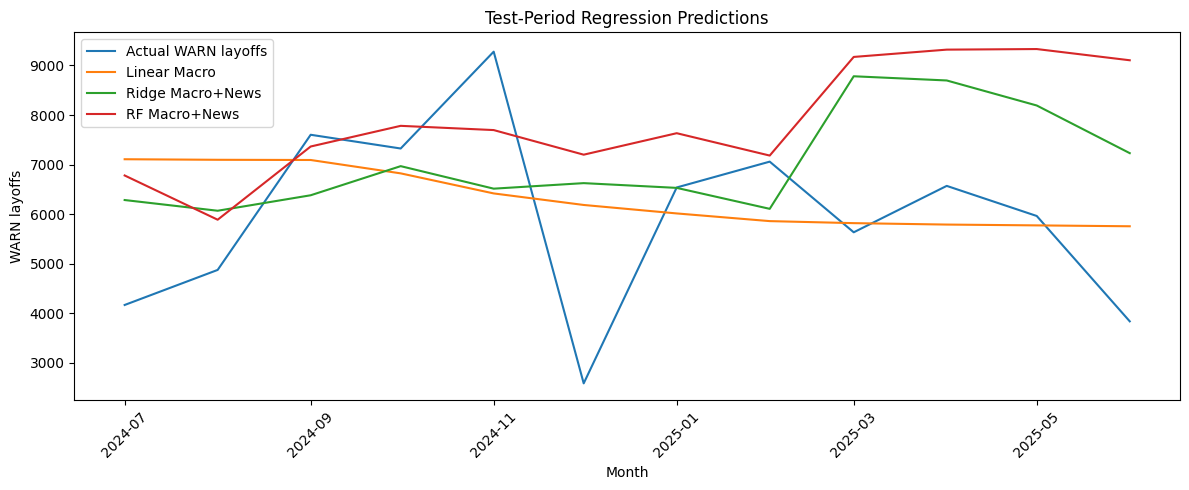

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(final_predictions["month"], final_predictions["warn_layoffs"], label="Actual WARN layoffs")
plt.plot(final_predictions["month"], final_predictions["pred_linear_macro"], label="Linear Macro")
plt.plot(final_predictions["month"], final_predictions["pred_ridge_macro_news"], label="Ridge Macro+News")
plt.plot(final_predictions["month"], final_predictions["pred_rf_macro_news"], label="RF Macro+News")
plt.title("Test-Period Regression Predictions")
plt.xlabel("Month")
plt.ylabel("WARN layoffs")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Build risk labels for classification

Important:
We define the Low / Medium / High thresholds using only the training period.

(to keep the evaluation cleaner and avoids using future information when defining classes)

In [16]:
train_threshold_source = master[master["split"] == "train"]["warn_layoffs"]

q1 = train_threshold_source.quantile(1/3)
q2 = train_threshold_source.quantile(2/3)

def assign_risk(x, q1, q2):
    if x <= q1:
        return "Low"
    elif x <= q2:
        return "Medium"
    else:
        return "High"

master["risk_level"] = master["warn_layoffs"].apply(lambda x: assign_risk(x, q1, q2))

master[["month", "warn_layoffs", "risk_level"]].head(12)

,month,warn_layoffs,risk_level
0,2020-07-01,32814,High
1,2020-08-01,15544,High
2,2020-09-01,14535,High
3,2020-10-01,10477,High
4,2020-11-01,9323,High
5,2020-12-01,19996,High
6,2021-01-01,8541,High
7,2021-02-01,3772,Low
8,2021-03-01,3848,Medium
9,2021-04-01,4122,Medium


## 10. Prepare classification dataset

We use the same lagged features as the final predictive feature set.

In [17]:
clf_features = macro_news_features
clf_df = master.dropna(subset=clf_features + ["risk_level"]).copy()

train_clf = clf_df[clf_df["split"] == "train"].copy()
test_clf = clf_df[clf_df["split"] == "test"].copy()

class_order = ["Low", "Medium", "High"]
train_clf["risk_level"] = pd.Categorical(train_clf["risk_level"], categories=class_order, ordered=True)
test_clf["risk_level"] = pd.Categorical(test_clf["risk_level"], categories=class_order, ordered=True)

X_train_clf = train_clf[clf_features]
X_test_clf = test_clf[clf_features]
y_train_clf = train_clf["risk_level"]
y_test_clf = test_clf["risk_level"]

print(train_clf.shape, test_clf.shape)

(40, 35) (12, 35)


## 11. Classification models

We fit:
1. Logistic Regression
2. Random Forest Classifier

The logistic model is more interpretable.
The random forest gives us a simple non-linear comparison.

In [20]:
logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

rf_clf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

In [21]:
logit_model.fit(X_train_clf, y_train_clf)
rf_clf_model.fit(X_train_clf, y_train_clf)

pred_logit = logit_model.predict(X_test_clf)
pred_rf_clf = rf_clf_model.predict(X_test_clf)

clf_metrics = pd.DataFrame([
    {
        "model_name": "Logistic Regression",
        "accuracy": accuracy_score(y_test_clf, pred_logit),
        "precision_macro": precision_score(y_test_clf, pred_logit, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test_clf, pred_logit, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test_clf, pred_logit, average="macro", zero_division=0)
    },
    {
        "model_name": "Random Forest Classifier",
        "accuracy": accuracy_score(y_test_clf, pred_rf_clf),
        "precision_macro": precision_score(y_test_clf, pred_rf_clf, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test_clf, pred_rf_clf, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test_clf, pred_rf_clf, average="macro", zero_division=0)
    }
]).sort_values("f1_macro", ascending=False)

clf_metrics

,model_name,accuracy,precision_macro,recall_macro,f1_macro
1,Random Forest Classifier,0.416667,0.433333,0.428571,0.301994
0,Logistic Regression,0.416667,0.257143,0.301587,0.273810


## 12. Confusion matrix for the better classifier

This helps us see which risk levels are easiest or hardest to classify.

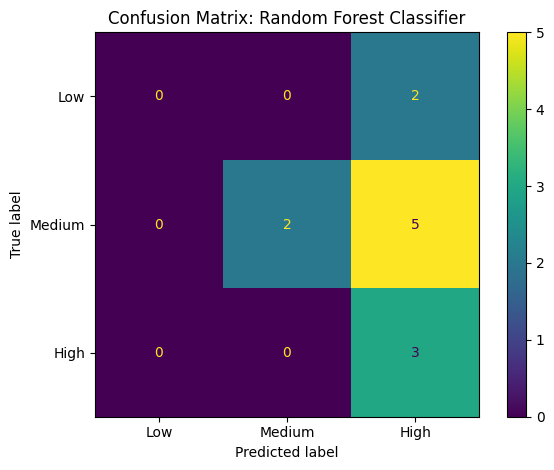

In [22]:
best_clf_name = clf_metrics.iloc[0]["model_name"]

if best_clf_name == "Logistic Regression":
    best_pred = pred_logit
else:
    best_pred = pred_rf_clf

cm = confusion_matrix(y_test_clf, best_pred, labels=class_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
disp.plot()
plt.title(f"Confusion Matrix: {best_clf_name}")
plt.tight_layout()
plt.show()

## 13. Risk prediction export table

We save the actual and predicted risk levels for the website.

In [23]:
risk_scores = test_clf[["month", "warn_layoffs", "risk_level", "split"]].copy()

logit_probs = logit_model.predict_proba(X_test_clf)
risk_scores["predicted_risk_logit"] = pred_logit
risk_scores["prob_low_logit"] = logit_probs[:, 0]
risk_scores["prob_medium_logit"] = logit_probs[:, 1]
risk_scores["prob_high_logit"] = logit_probs[:, 2]

risk_scores["predicted_risk_rf"] = pred_rf_clf

risk_scores.head()

,month,warn_layoffs,risk_level,split,predicted_risk_logit,prob_low_logit,prob_medium_logit,prob_high_logit,predicted_risk_rf
48,2024-07-01,4169,Medium,test,Medium,0.372716,0.056497,0.570787,Medium
49,2024-08-01,4876,Medium,test,Medium,0.343307,0.077343,0.579350,Medium
50,2024-09-01,7602,High,test,Medium,0.448967,0.043959,0.507074,High
51,2024-10-01,7325,High,test,High,0.570753,0.015872,0.413376,High
52,2024-11-01,9278,High,test,Medium,0.434696,0.028267,0.537036,High


## 14. Feature importance export

We save simple importance outputs for both regression and classification.

For linear-style models, we use coefficients.
For random forest models, we use feature importance values.

In [25]:
feature_rows = []

# Ridge coefficients
ridge_final = ridge_out["model"].named_steps["ridge"]
for feature, coef in zip(macro_news_features, ridge_final.coef_):
    feature_rows.append({
        "model_name": "Ridge Regression",
        "task": "regression",
        "feature": feature,
        "importance": coef
    })

# RF regressor feature importances
for feature, imp in zip(macro_news_features, rf_reg_model.feature_importances_):
    feature_rows.append({
        "model_name": "Random Forest Regressor",
        "task": "regression",
        "feature": feature,
        "importance": imp
    })

# Logistic regression coefficients (average absolute coefficient across classes)
logit_final = logit_model.named_steps["logit"]
logit_abs_mean = np.mean(np.abs(logit_final.coef_), axis=0)

for feature, coef in zip(clf_features, logit_abs_mean):
    feature_rows.append({
        "model_name": "Logistic Regression",
        "task": "classification",
        "feature": feature,
        "importance": coef
    })

# RF classifier importances
for feature, imp in zip(clf_features, rf_clf_model.feature_importances_):
    feature_rows.append({
        "model_name": "Random Forest Classifier",
        "task": "classification",
        "feature": feature,
        "importance": imp
    })

feature_importance_df = pd.DataFrame(feature_rows)
feature_importance_df.head()

,model_name,task,feature,importance
0,Ridge Regression,regression,ca_unemployment_rate_lag3,-0.097137
1,Ridge Regression,regression,fed_funds_rate_lag1,0.145811
2,Ridge Regression,regression,indeed_job_postings_index_lag1,-0.075153
3,Ridge Regression,regression,news_volume_log1p_lag1,0.037493
4,Ridge Regression,regression,news_tone_lag1,-0.064157


## 15. Final metrics table

We combine regression and classification metrics into one export file for the app and documentation.

In [26]:
reg_metrics_export = reg_metrics_df.copy()
reg_metrics_export["task"] = "regression"

clf_metrics_export = clf_metrics.copy()
clf_metrics_export["task"] = "classification"

model_metrics = pd.concat([reg_metrics_export, clf_metrics_export], ignore_index=True, sort=False)
model_metrics

,model_name,feature_set,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2,task,accuracy,precision_macro,recall_macro,f1_macro
0,Linear Regression (Macro only),macro,0.363297,0.359832,0.271989,0.262846,0.516602,-0.133571,regression,NaN,NaN,NaN,NaN
1,Ridge Regression (Macro + News),macro_news,0.360066,0.413917,0.257167,0.330682,0.525161,-0.499944,regression,NaN,NaN,NaN,NaN
2,Random Forest Regressor (Macro + News),macro_news,0.241144,0.473248,0.175980,0.358031,0.787022,-0.960763,regression,NaN,NaN,NaN,NaN
3,Random Forest Classifier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,classification,0.416667,0.433333,0.428571,0.301994
4,Logistic Regression,NaN,NaN,NaN,NaN,NaN,NaN,NaN,classification,0.416667,0.257143,0.301587,0.273810


## 16. Save final outputs for the website

These files will feed the dashboard later.

In [27]:
os.makedirs("../data/processed", exist_ok=True)

final_predictions.to_csv("../data/processed/final_predictions.csv", index=False)
risk_scores.to_csv("../data/processed/final_risk_scores.csv", index=False)
feature_importance_df.to_csv("../data/processed/feature_importance.csv", index=False)
model_metrics.to_csv("../data/processed/model_metrics.csv", index=False)

print("Saved:")
print("- ../data/processed/final_predictions.csv")
print("- ../data/processed/final_risk_scores.csv")
print("- ../data/processed/feature_importance.csv")
print("- ../data/processed/model_metrics.csv")

Saved:
- ../data/processed/final_predictions.csv
- ../data/processed/final_risk_scores.csv
- ../data/processed/feature_importance.csv
- ../data/processed/model_metrics.csv


## 17. Final notes

What this notebook gives us:
- one clean regression comparison
- one clean risk classification comparison
- exported files ready for the website

What we will improve after running this:
- choose the best final regression model
- choose the best final classifier
- decide what to display on the homepage